
테스트 파일 처리 중: test_looking_l01.csv
4/4 [==============================] - 2s 45ms/step


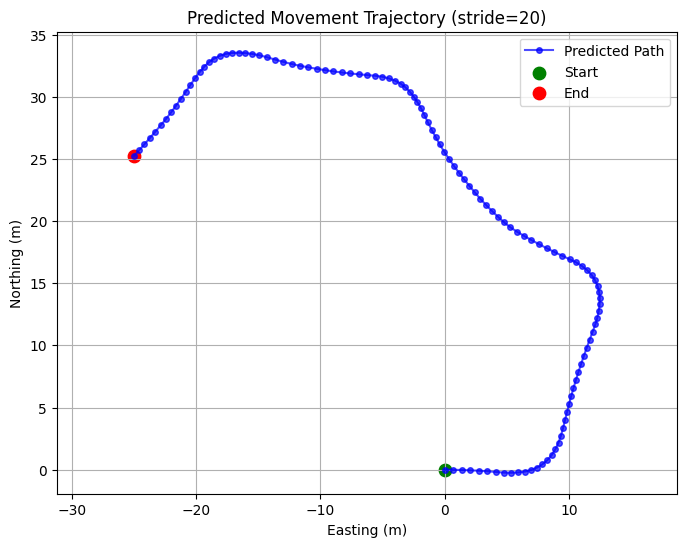

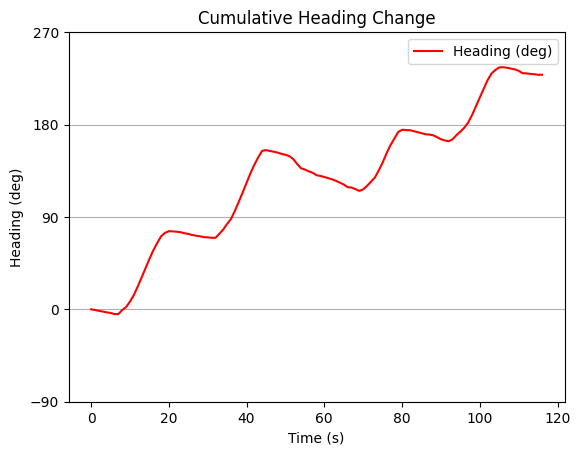


테스트 파일 처리 중: test_looking_l02.csv
4/4 [==============================] - 0s 11ms/step


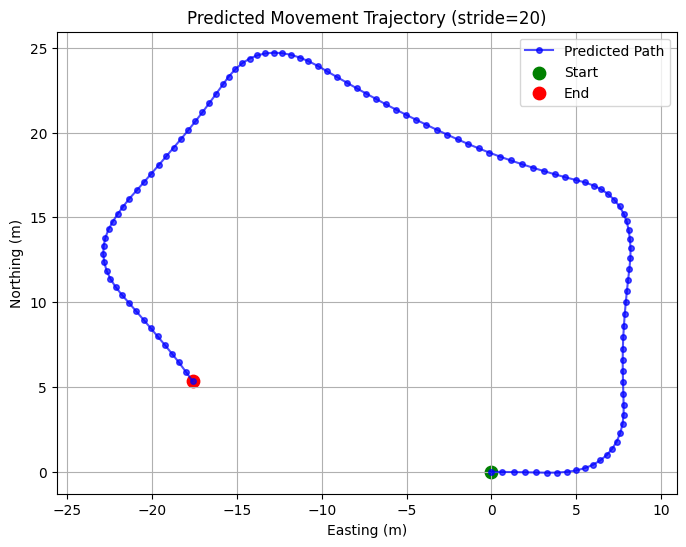

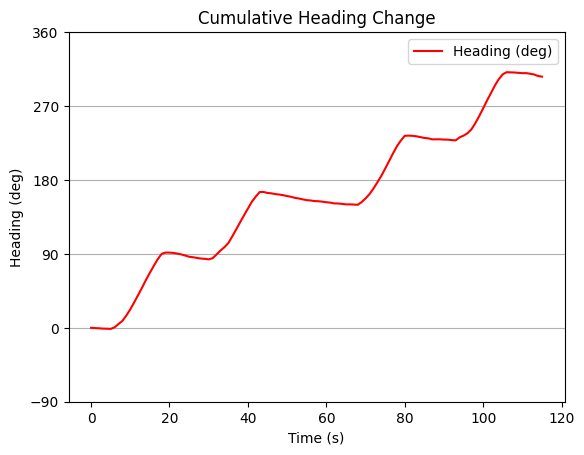


테스트 파일 처리 중: test_looking_l03.csv
4/4 [==============================] - 0s 13ms/step


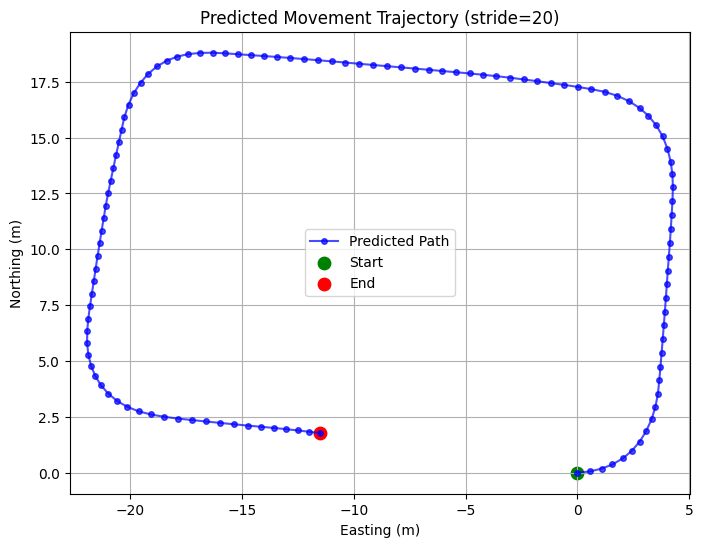

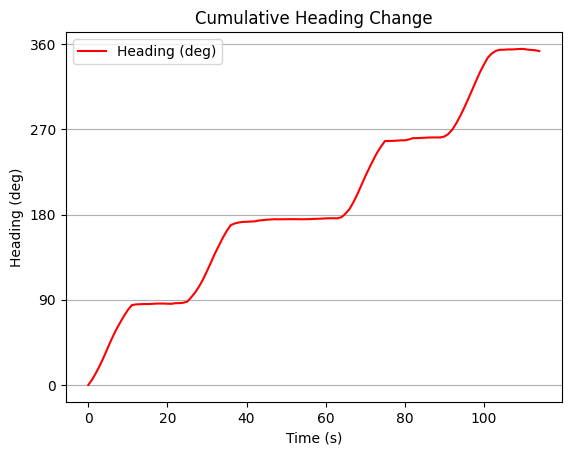


테스트 파일 처리 중: test_looking_l04.csv
4/4 [==============================] - 0s 11ms/step


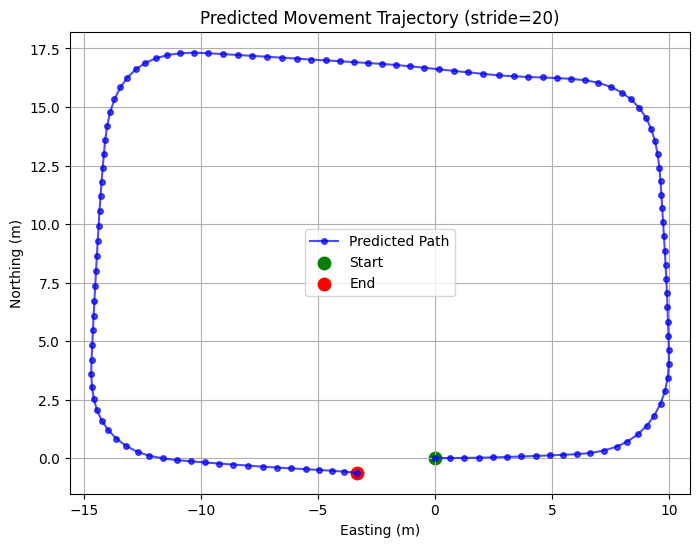

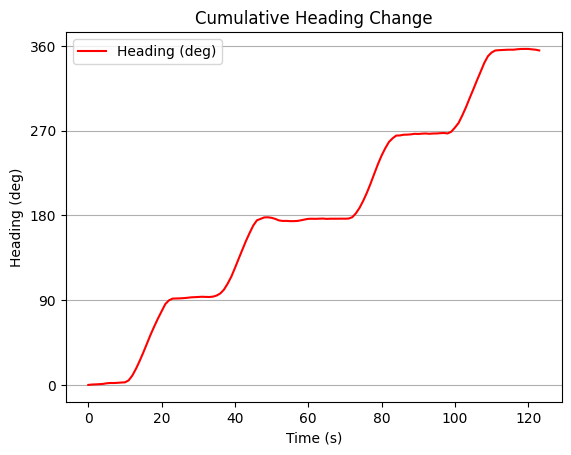


테스트 파일 처리 중: test_looking_l05.csv
4/4 [==============================] - 0s 12ms/step


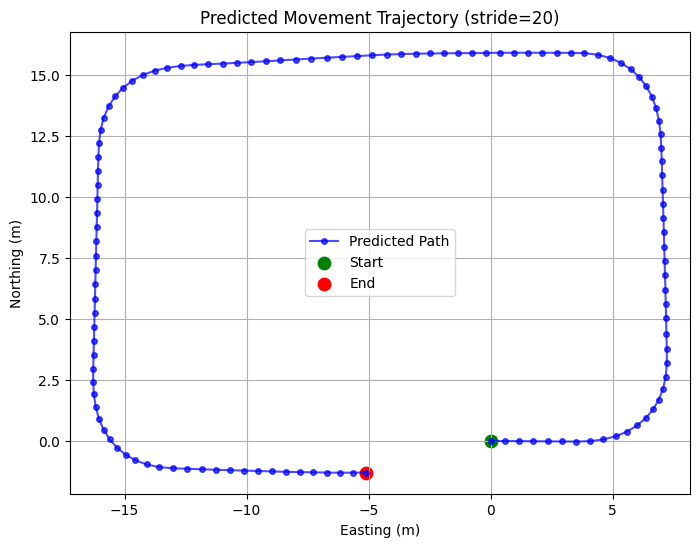

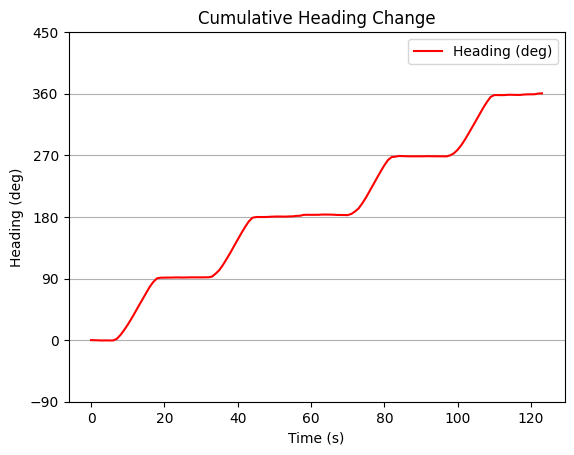


테스트 파일 처리 중: test_looking_l06.csv
4/4 [==============================] - 0s 12ms/step


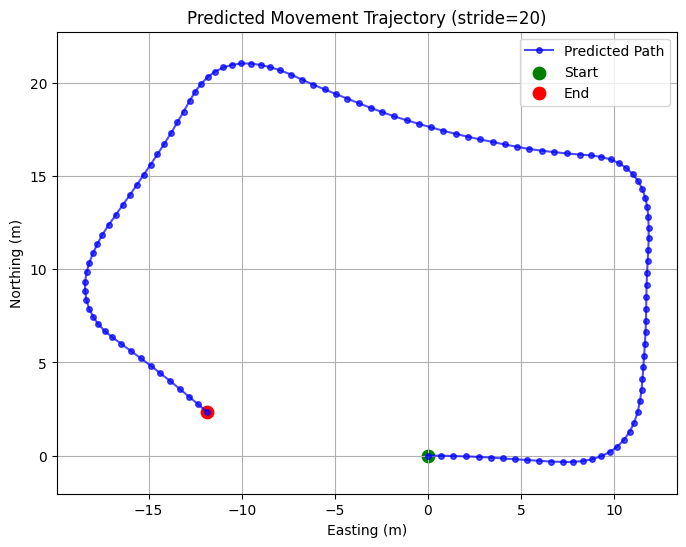

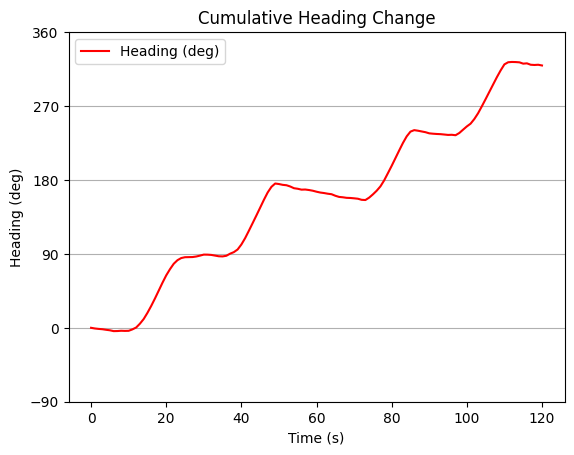


테스트 파일 처리 중: test_looking_l07.csv
4/4 [==============================] - 0s 23ms/step


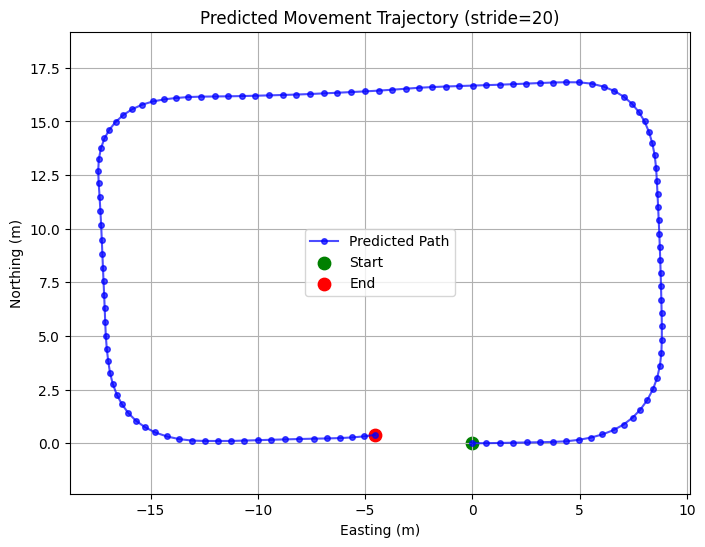

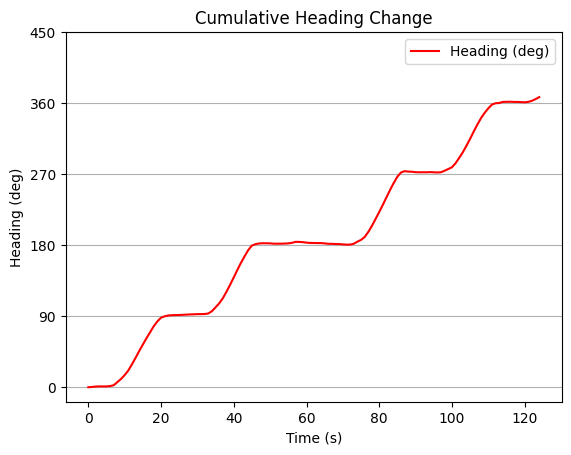


테스트 파일 처리 중: test_looking_l08.csv
4/4 [==============================] - 0s 22ms/step


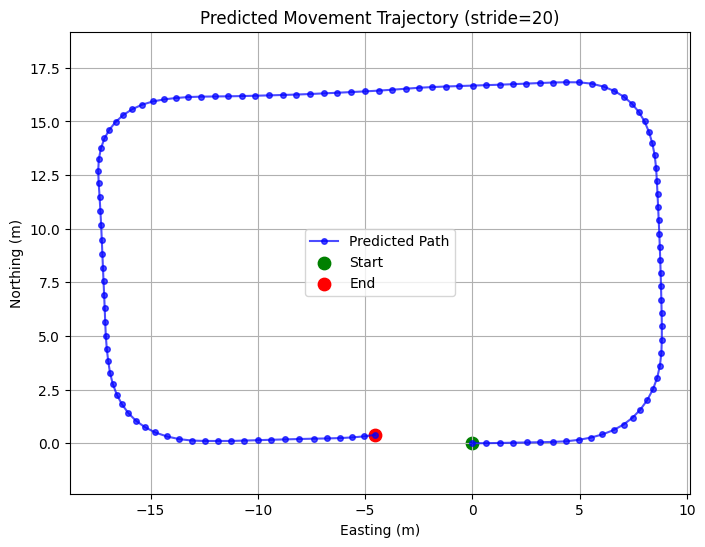

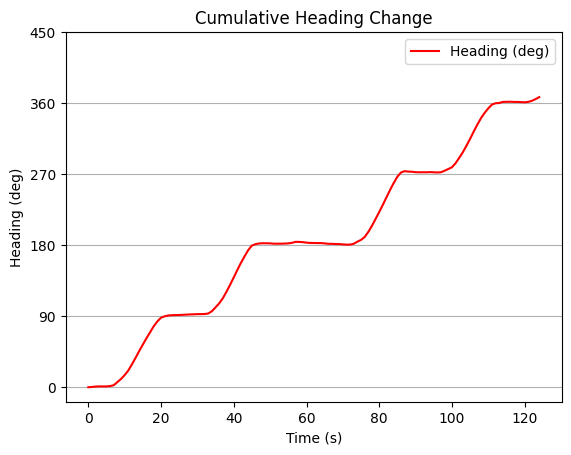


테스트 파일 처리 중: test_looking_l09.csv
4/4 [==============================] - 0s 25ms/step


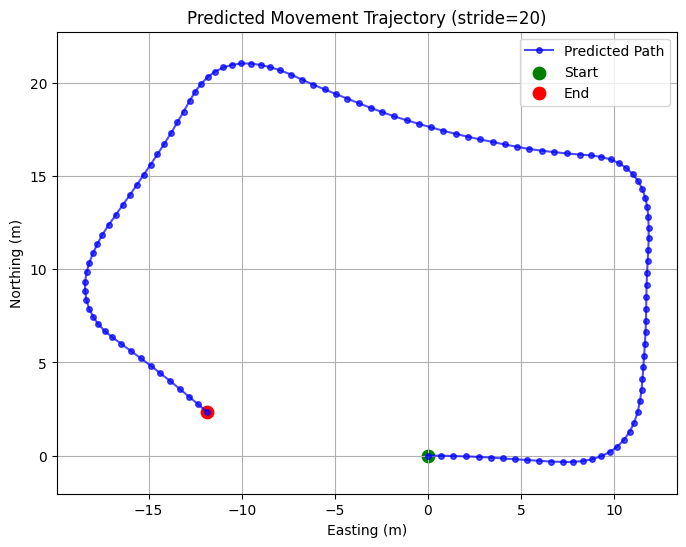

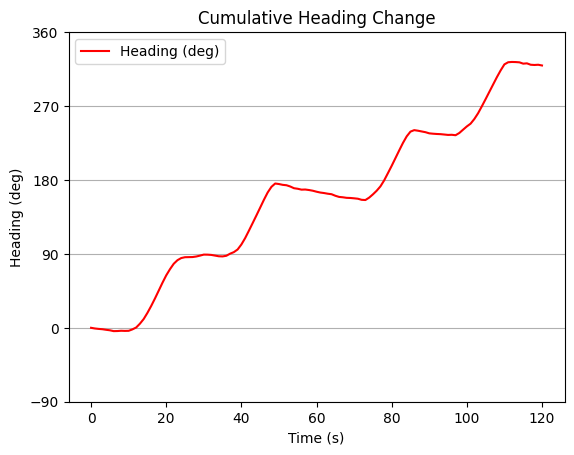


테스트 파일 처리 중: test_looking_r01.csv
4/4 [==============================] - 0s 21ms/step


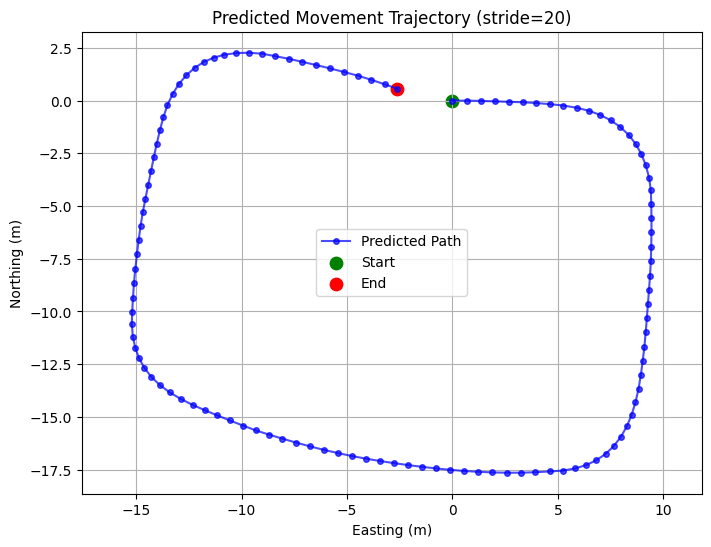

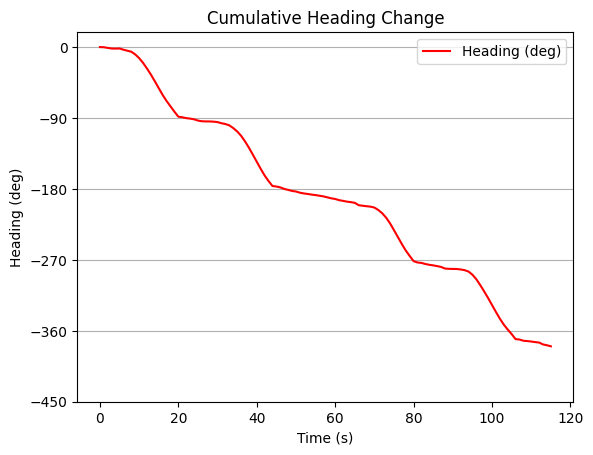


테스트 파일 처리 중: test_looking_r02.csv
4/4 [==============================] - 0s 21ms/step


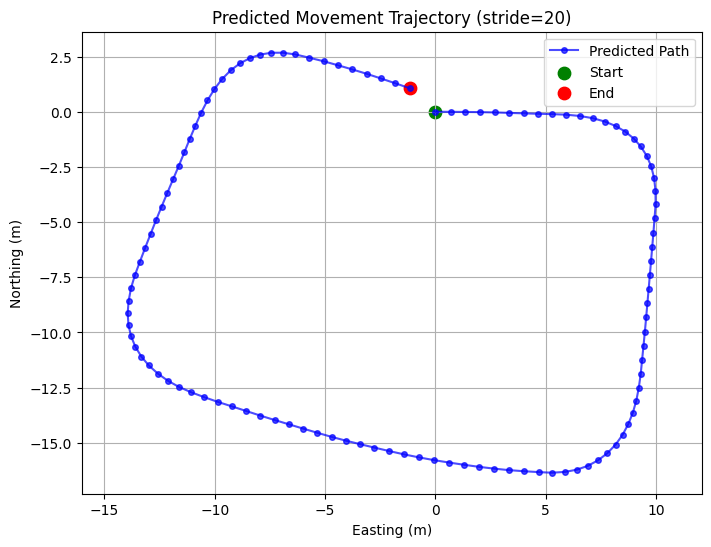

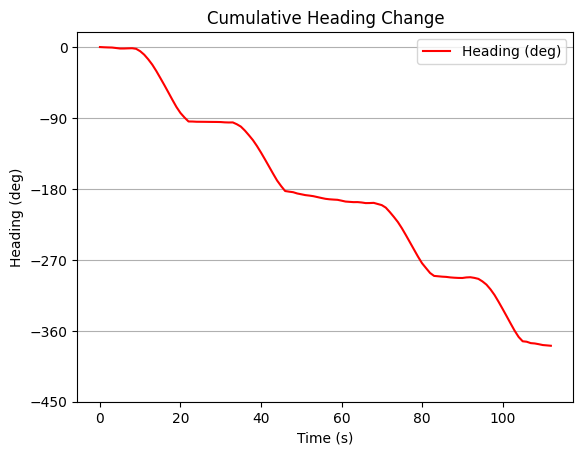


테스트 파일 처리 중: test_looking_r03.csv
4/4 [==============================] - 0s 23ms/step


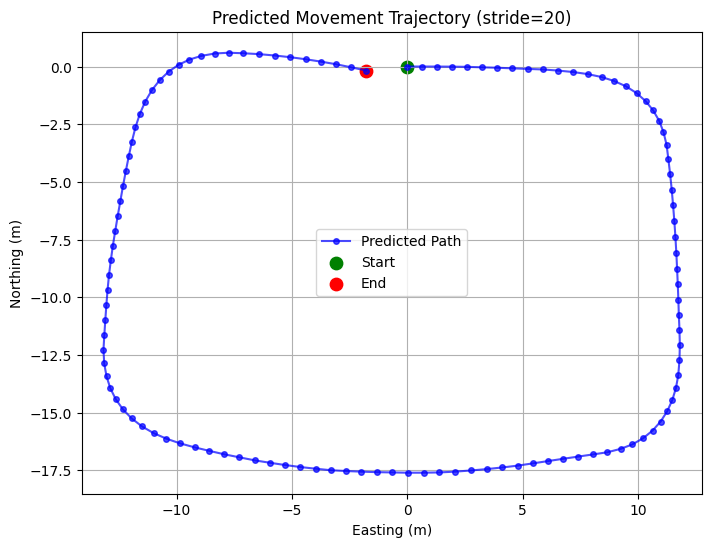

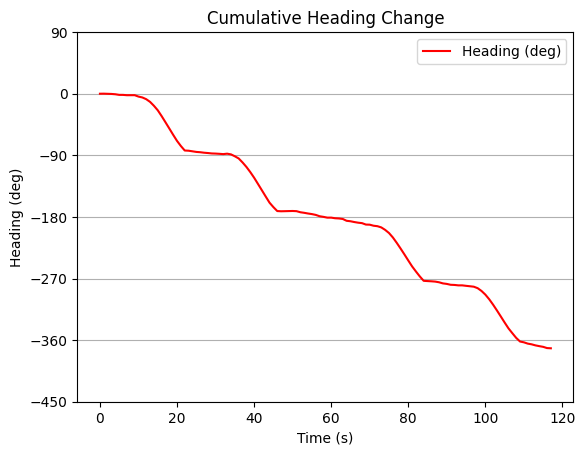


테스트 파일 처리 중: test_looking_r04.csv
4/4 [==============================] - 0s 26ms/step


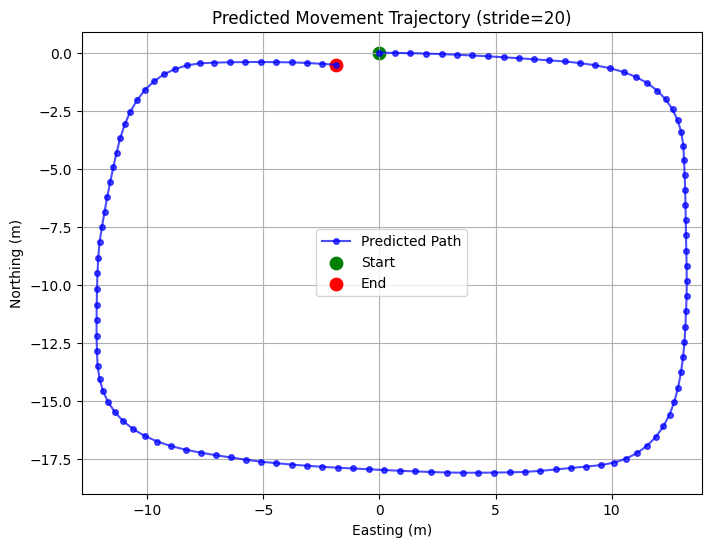

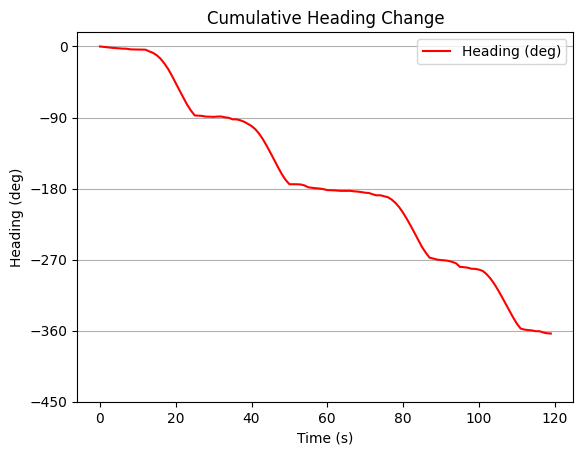


테스트 파일 처리 중: test_looking_r05.csv
4/4 [==============================] - 0s 22ms/step


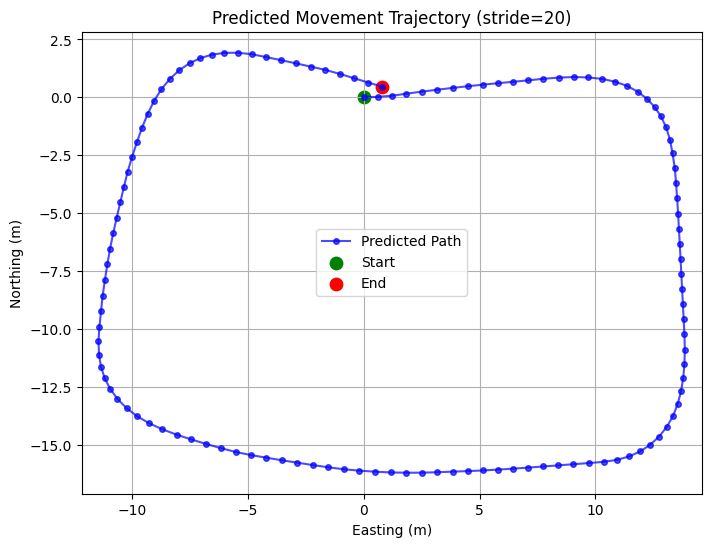

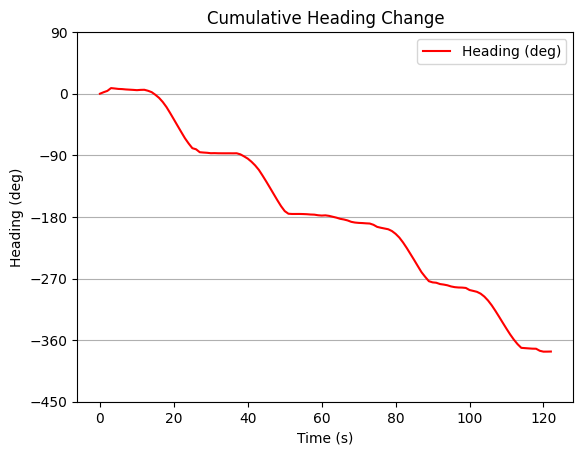


테스트 파일 처리 중: test_looking_r06.csv
4/4 [==============================] - 0s 22ms/step


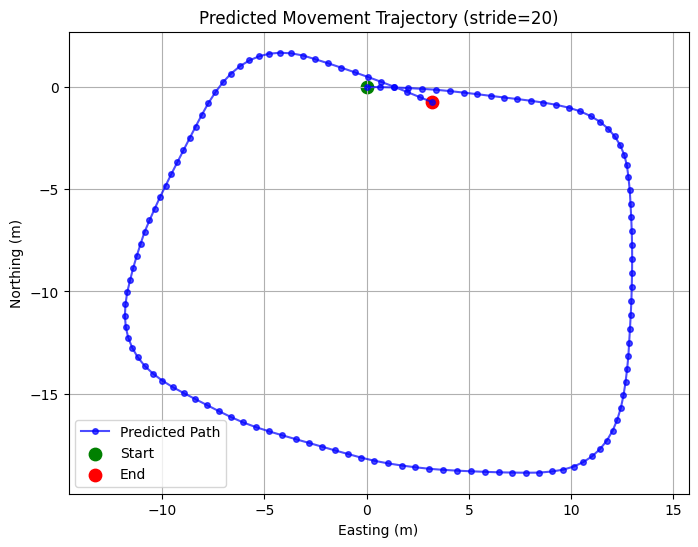

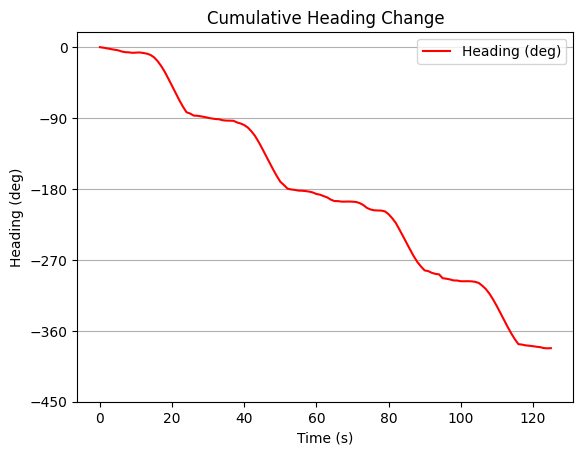


테스트 파일 처리 중: test_looking_r07.csv
4/4 [==============================] - 0s 22ms/step


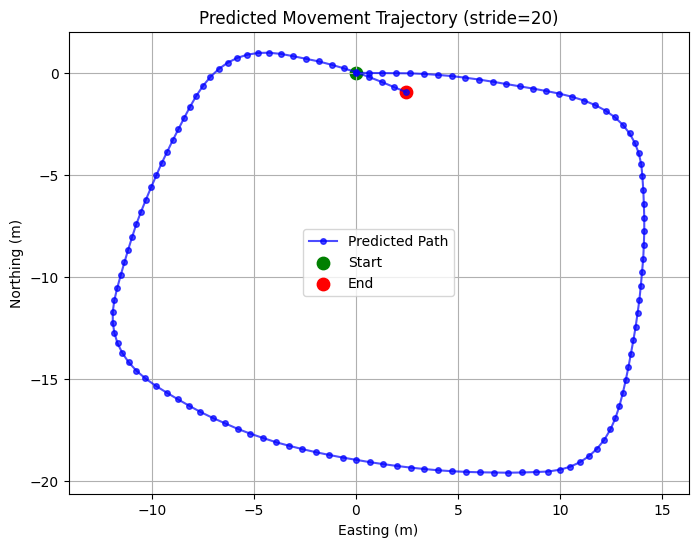

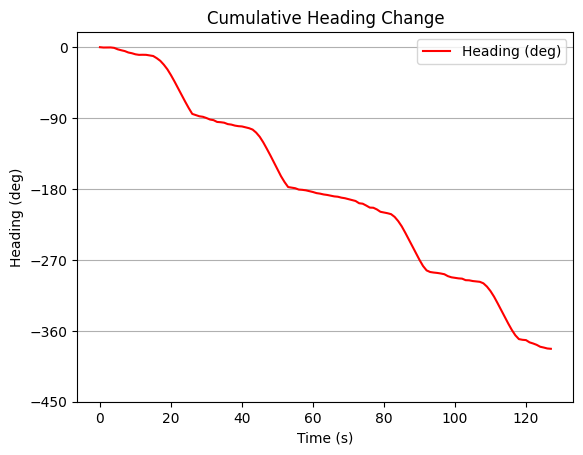


테스트 파일 처리 중: test_looking_r08.csv
4/4 [==============================] - 0s 23ms/step


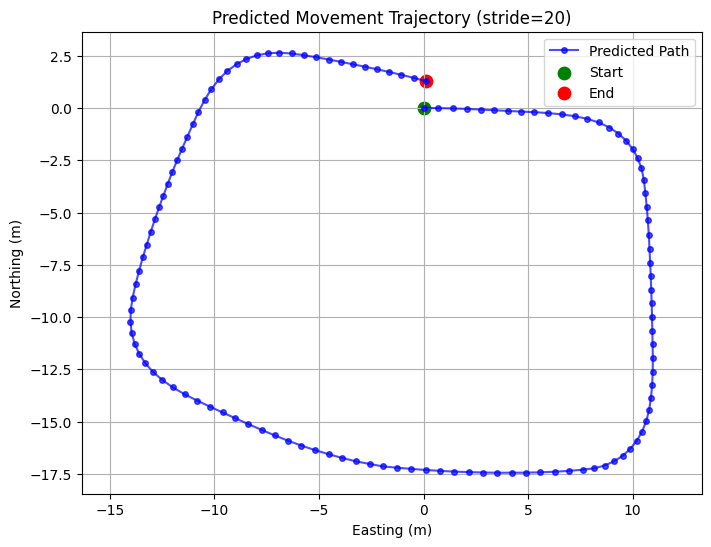

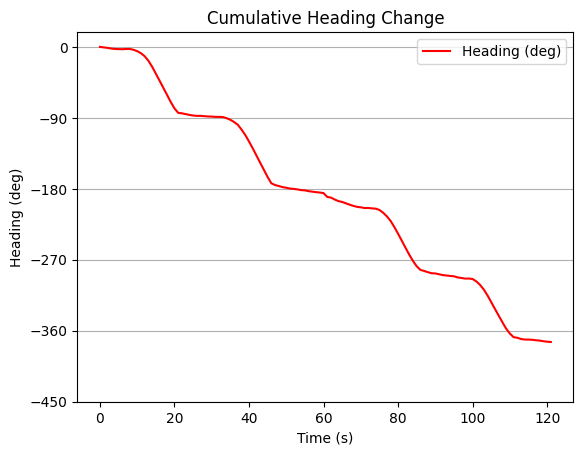


테스트 파일 처리 중: test_looking_r09.csv
4/4 [==============================] - 0s 21ms/step


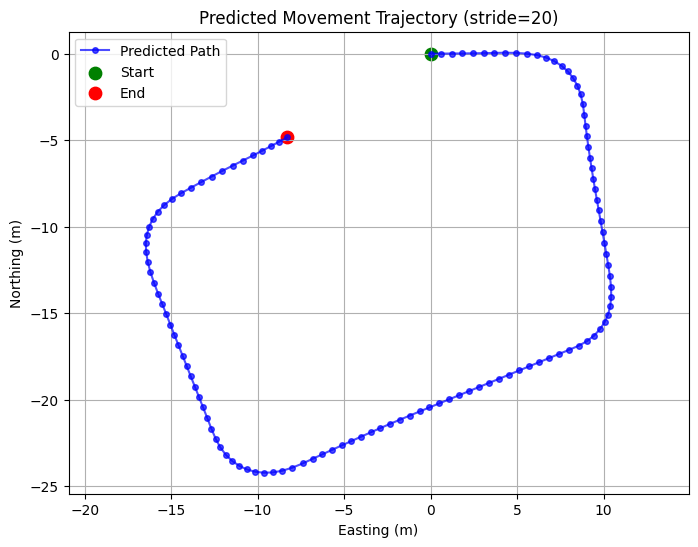

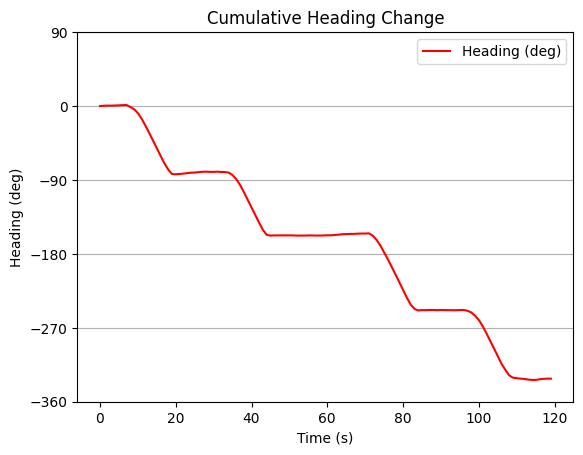


테스트 파일 처리 중: test_looking_r10.csv
4/4 [==============================] - 0s 22ms/step


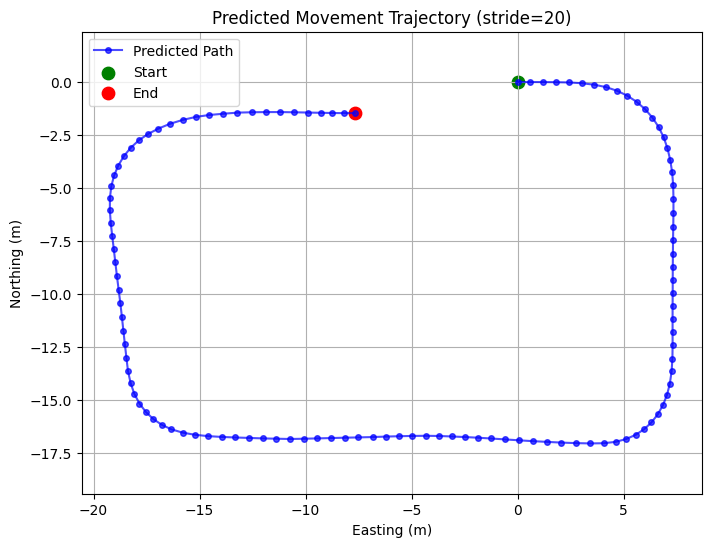

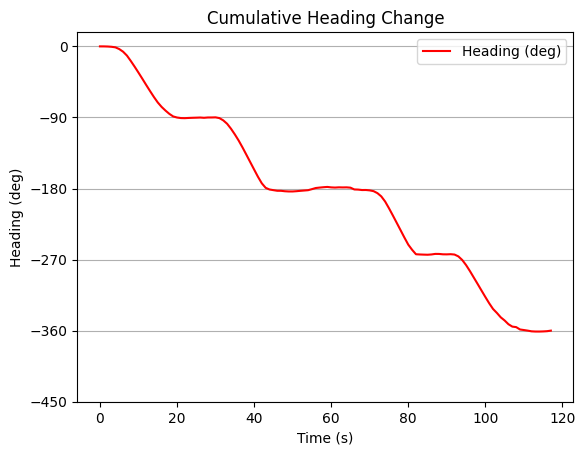


테스트 파일 처리 중: test_looking_3loop_l01.csv
12/12 [==============================] - 0s 24ms/step


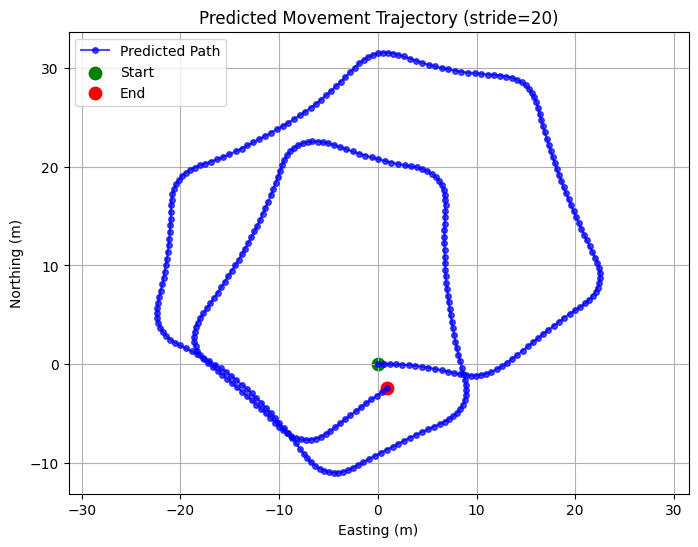

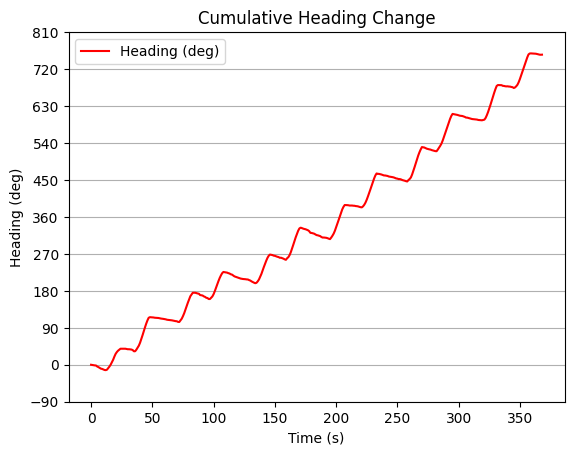


테스트 파일 처리 중: test_looking_3loop_r01.csv
12/12 [==============================] - 0s 13ms/step


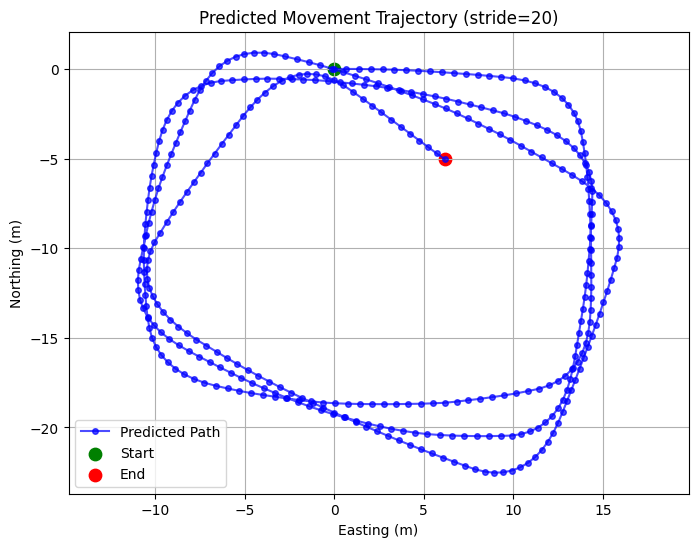

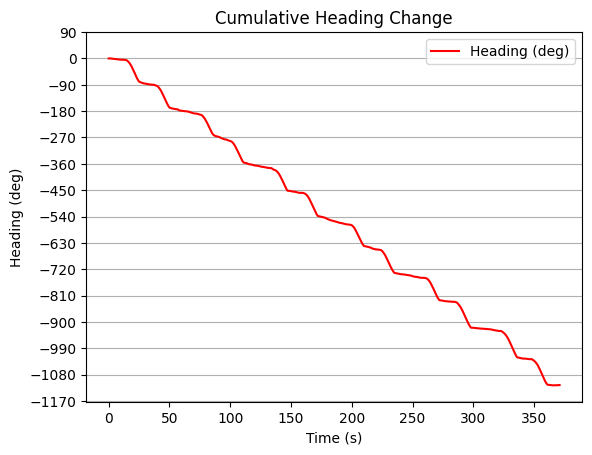


테스트 파일 처리 중: test_looking_3loop_r02.csv
13/13 [==============================] - 0s 12ms/step


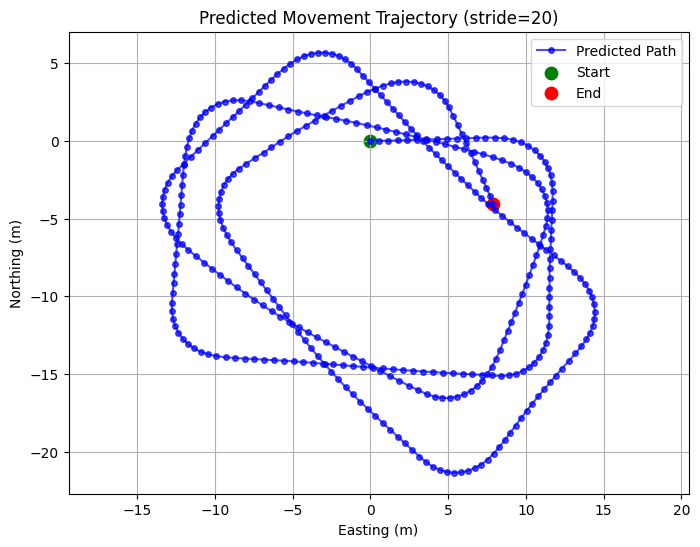

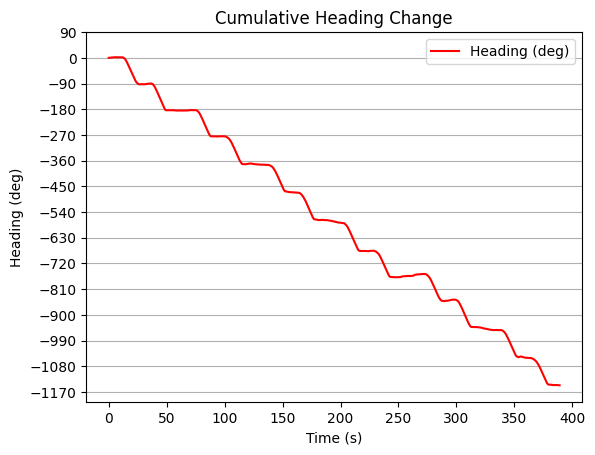


테스트 파일 처리 중: test_looking_5loop_l01.csv
21/21 [==============================] - 0s 13ms/step


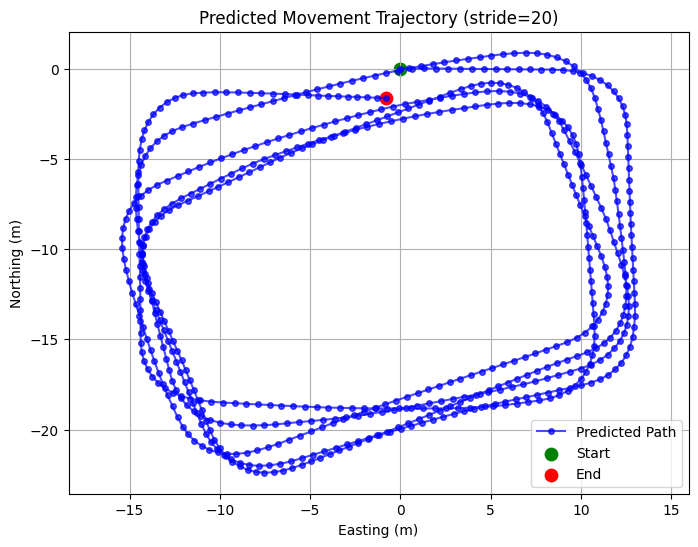

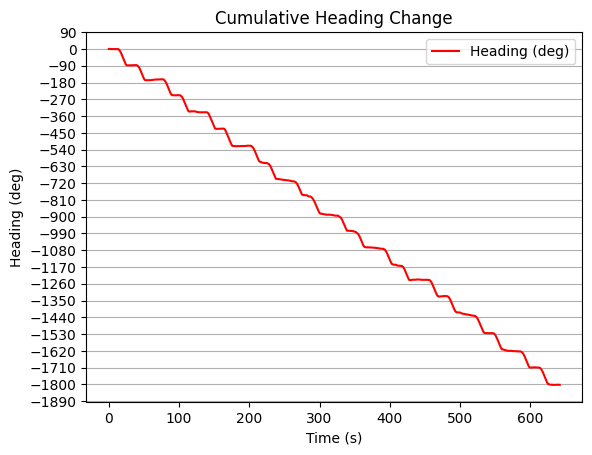


테스트 파일 처리 중: test_looking_5loop_l02.csv
16/16 [==============================] - 0s 12ms/step


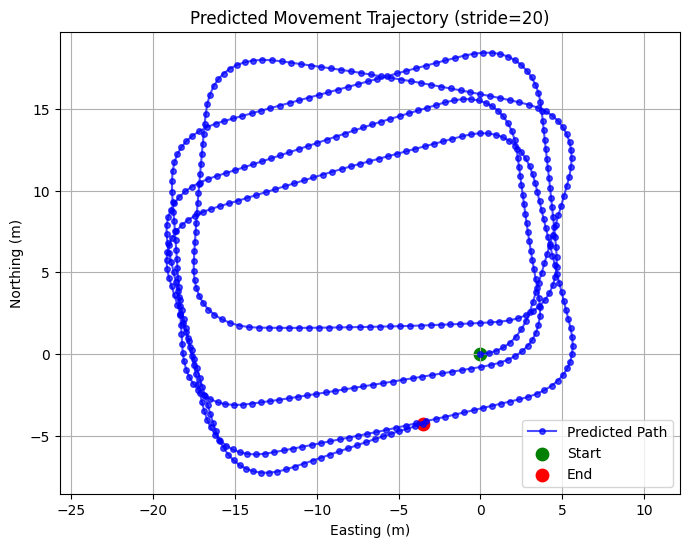

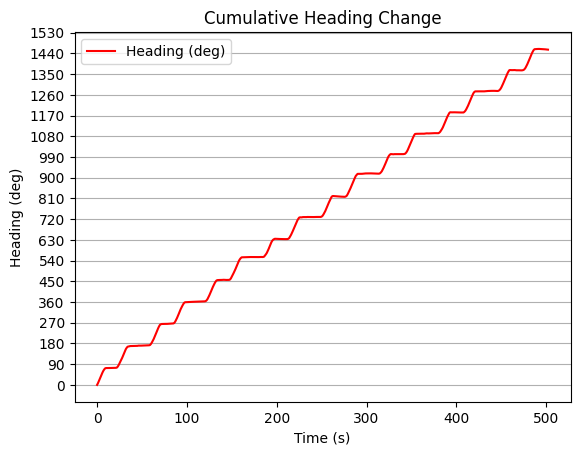


테스트 파일 처리 중: test_swing_l01.csv
4/4 [==============================] - 0s 12ms/step


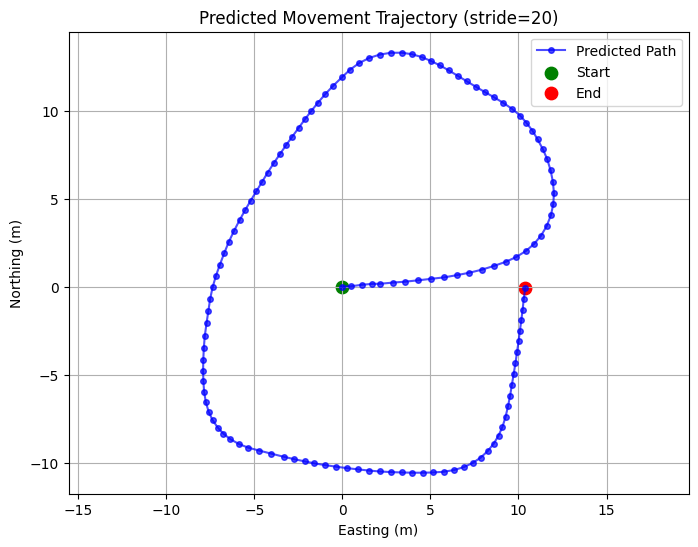

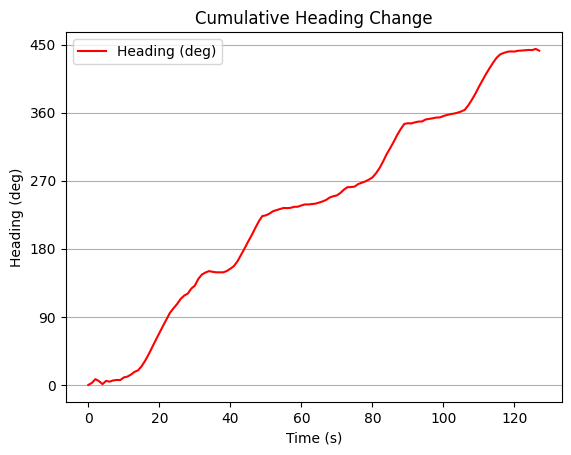


테스트 파일 처리 중: test_swing_l02.csv
4/4 [==============================] - 0s 12ms/step


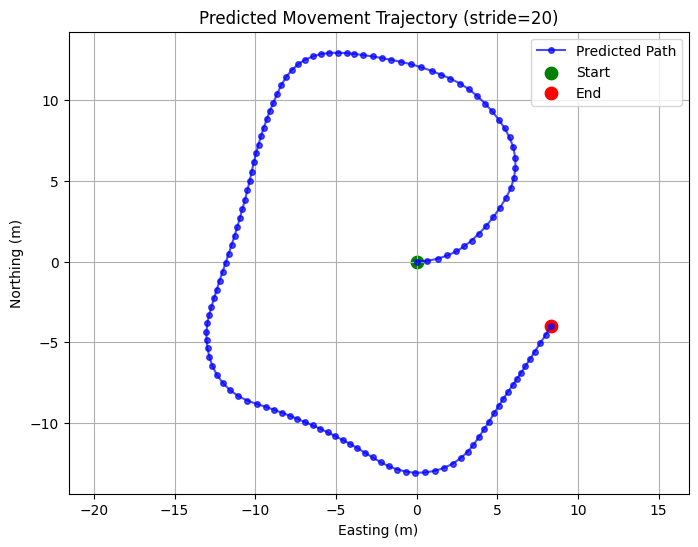

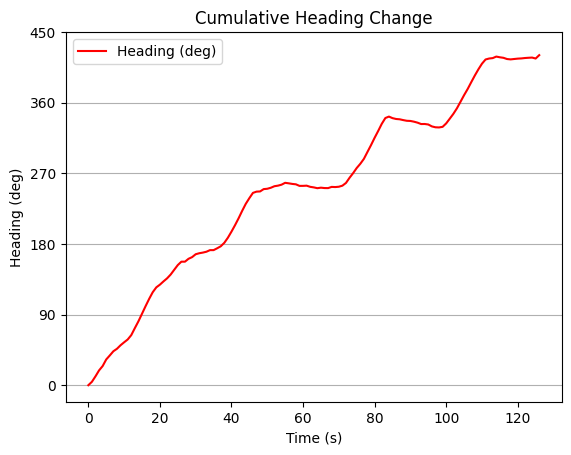


테스트 파일 처리 중: test_swing_l03.csv
4/4 [==============================] - 0s 12ms/step


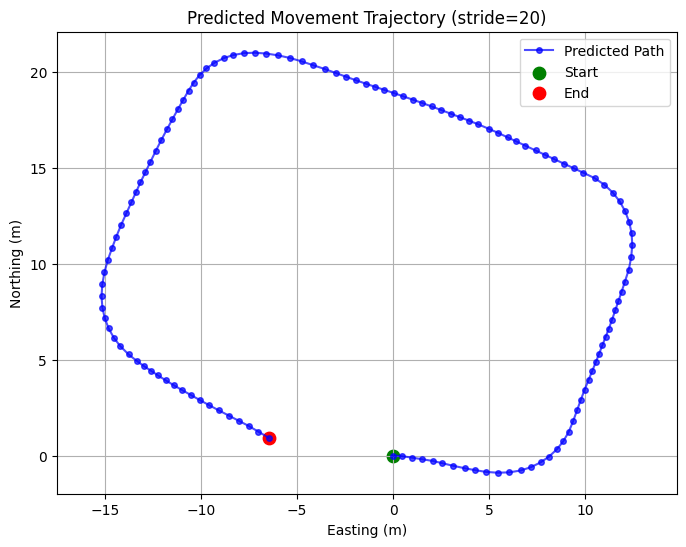

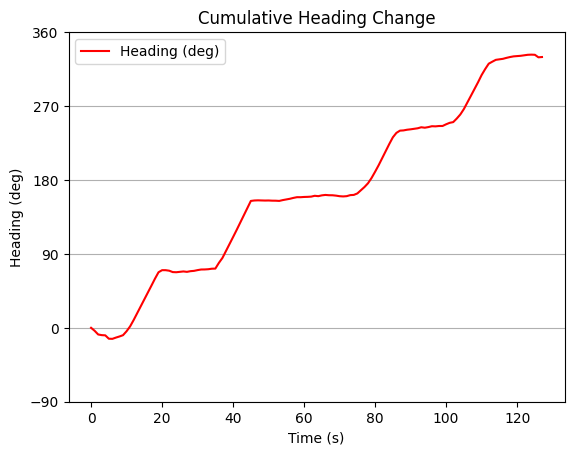


테스트 파일 처리 중: test_swing_l04.csv
4/4 [==============================] - 0s 13ms/step


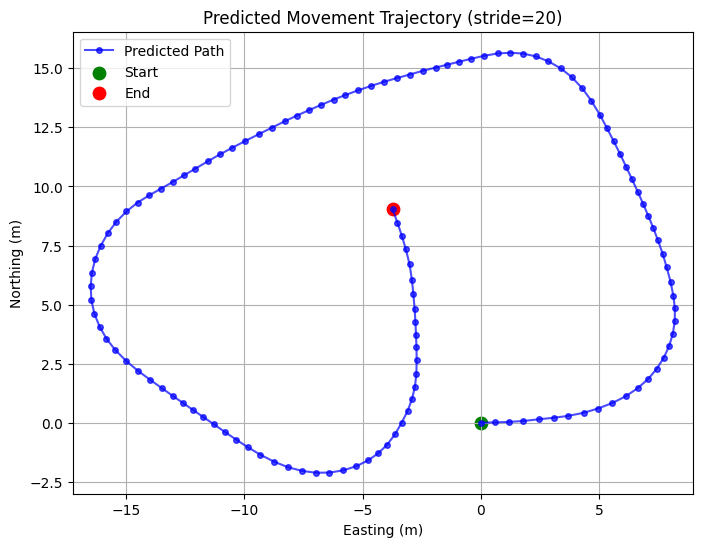

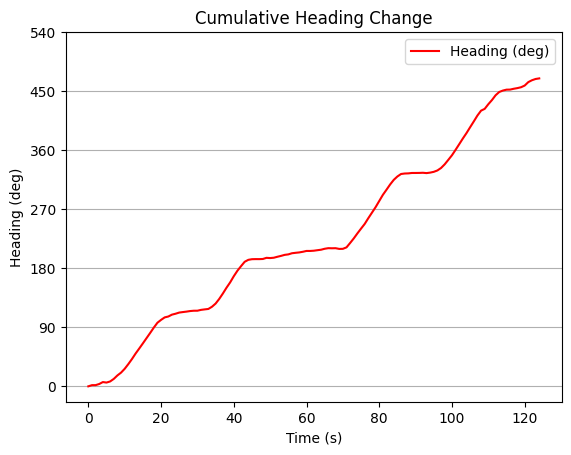


테스트 파일 처리 중: test_swing_l05.csv
4/4 [==============================] - 0s 19ms/step


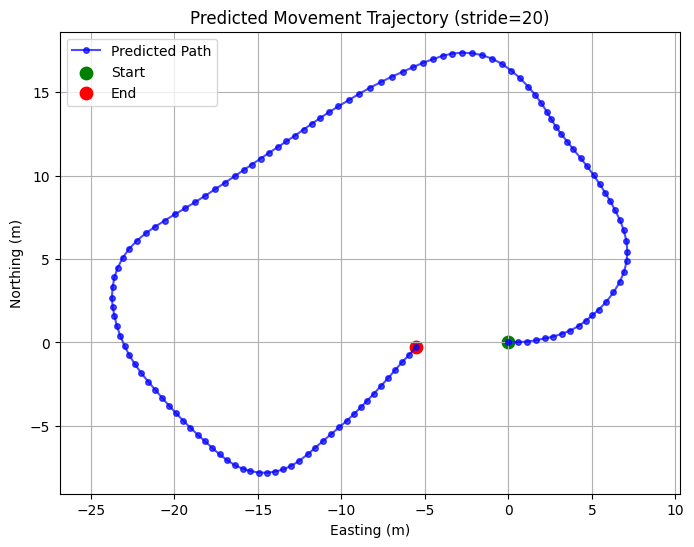

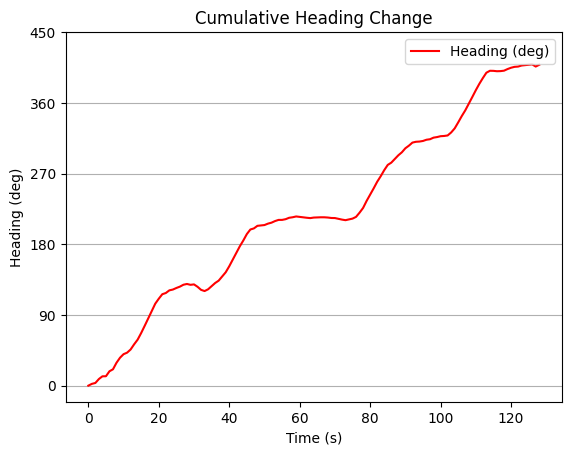


테스트 파일 처리 중: test_swing_l06.csv
4/4 [==============================] - 0s 19ms/step


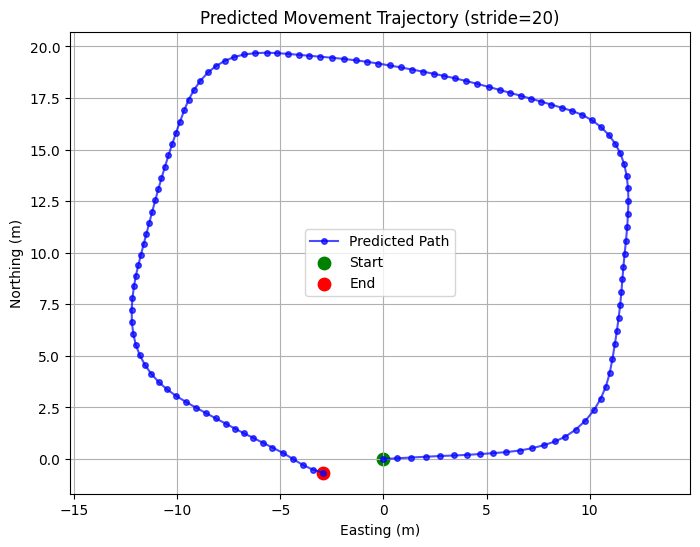

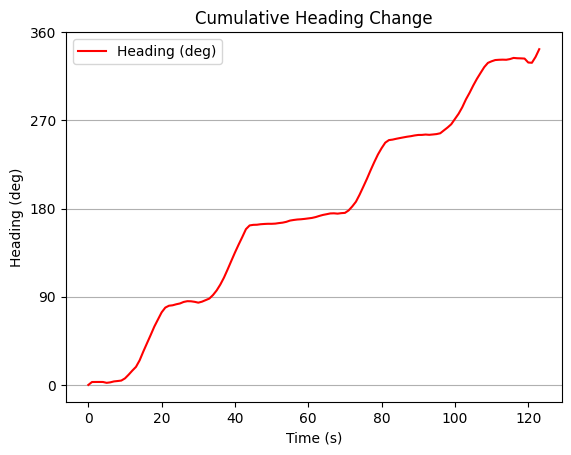


테스트 파일 처리 중: test_swing_r01.csv
4/4 [==============================] - 0s 21ms/step


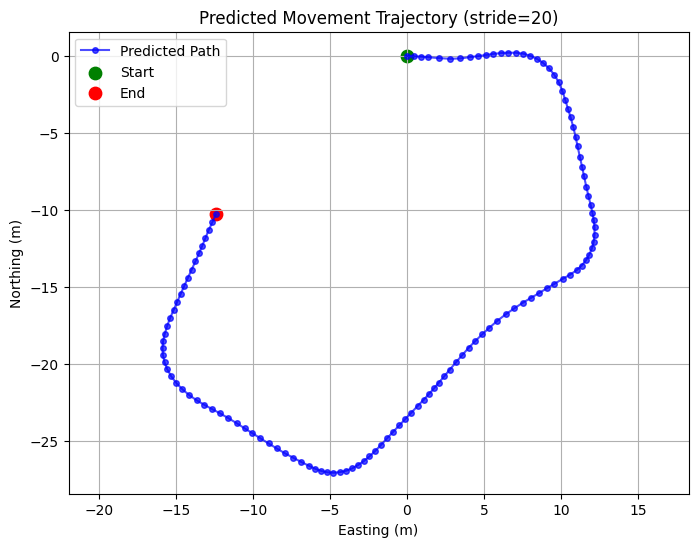

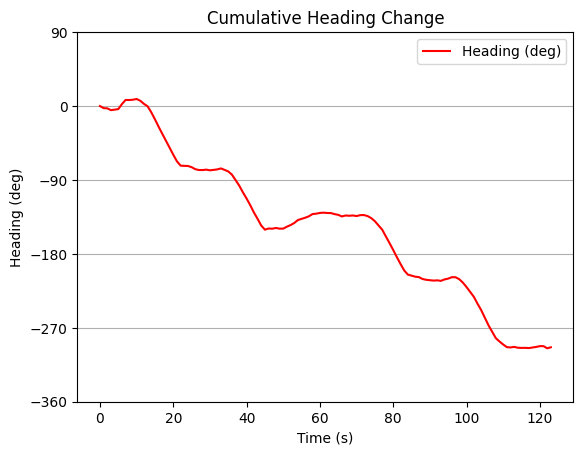


테스트 파일 처리 중: test_swing_r02.csv
4/4 [==============================] - 0s 23ms/step


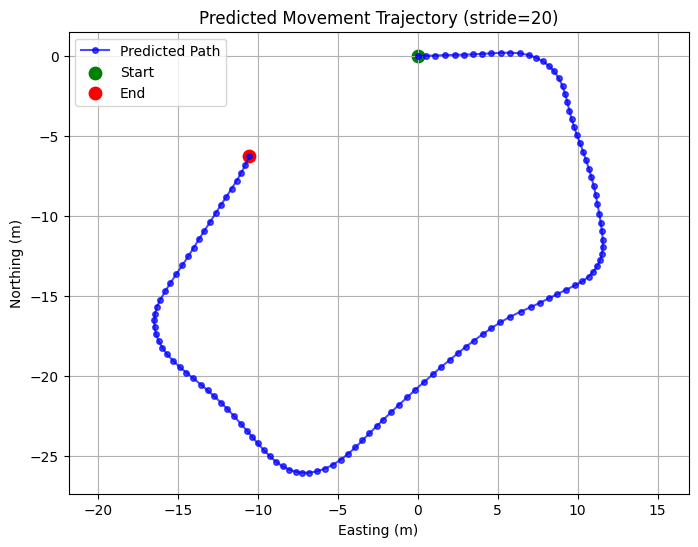

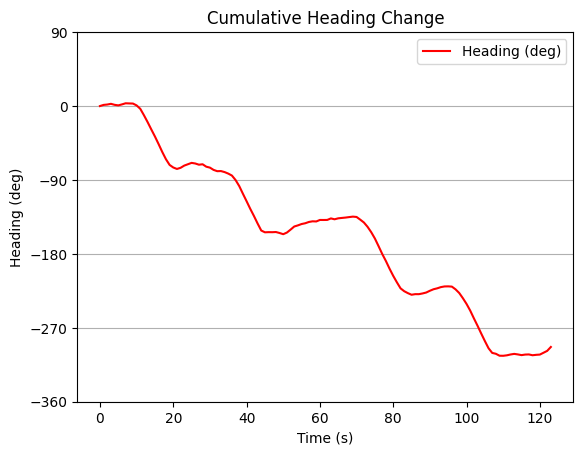


테스트 파일 처리 중: test_swing_r03.csv
4/4 [==============================] - 0s 23ms/step


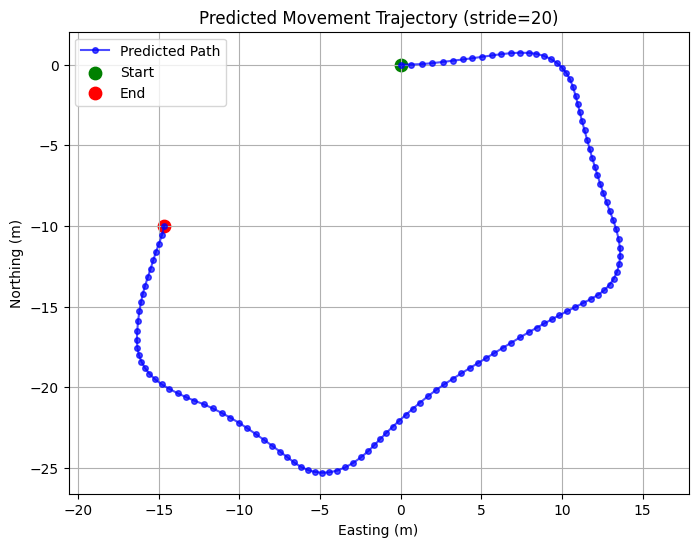

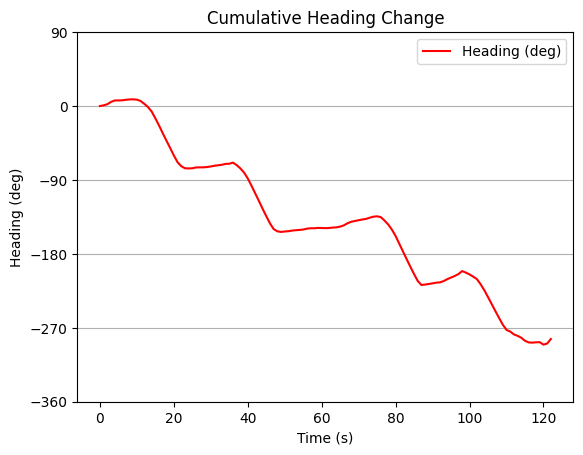


테스트 파일 처리 중: test_swing_r04.csv
4/4 [==============================] - 0s 26ms/step


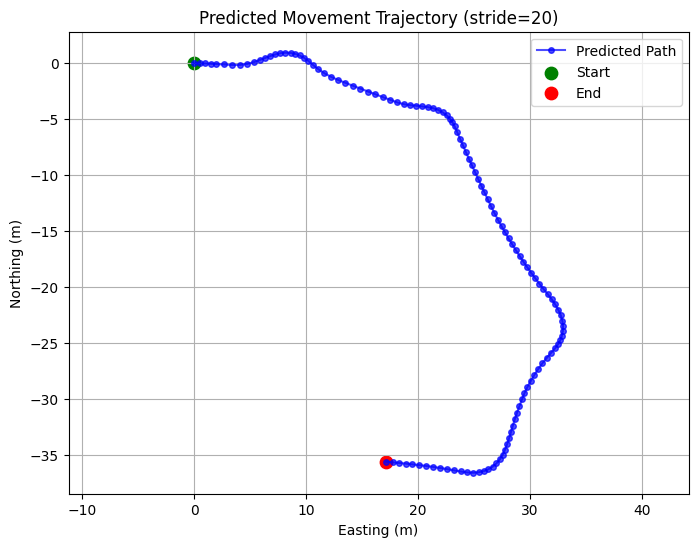

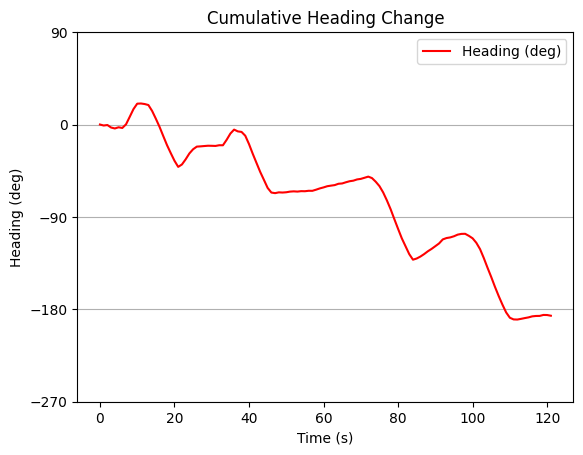


테스트 파일 처리 중: test_swing_r05.csv
4/4 [==============================] - 0s 24ms/step


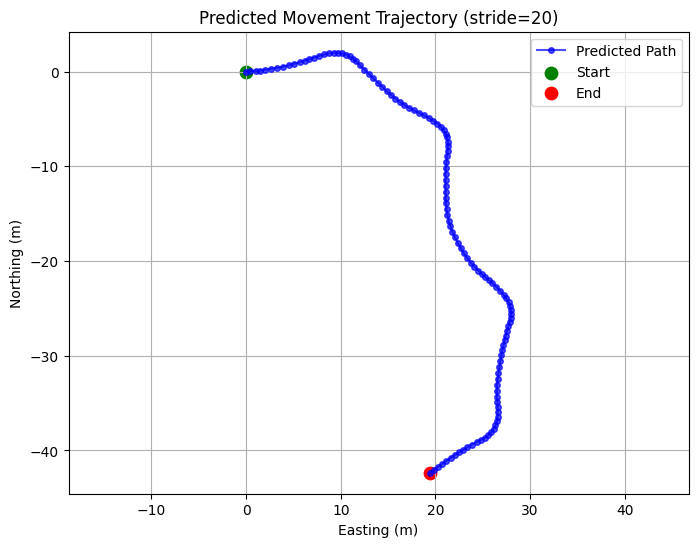

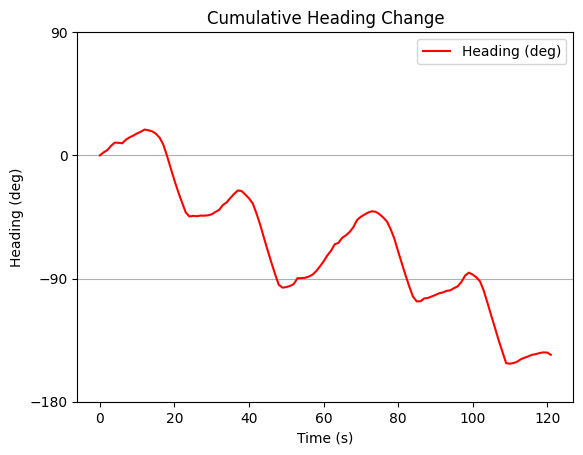


테스트 파일 처리 중: test_swing_r06.csv
4/4 [==============================] - 0s 26ms/step


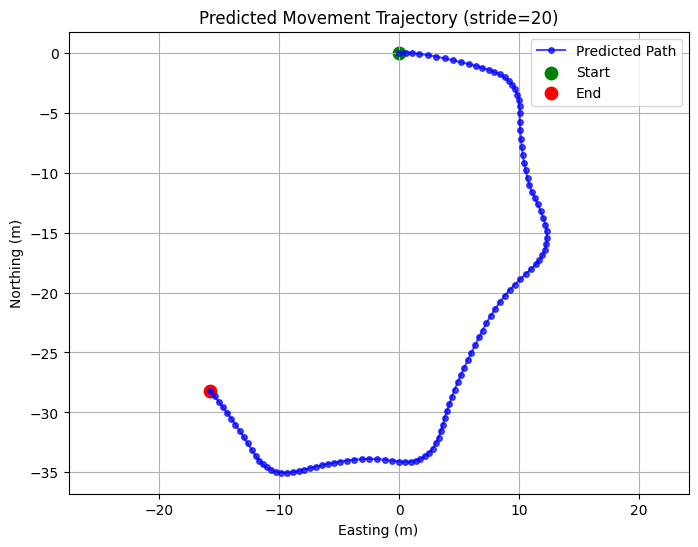

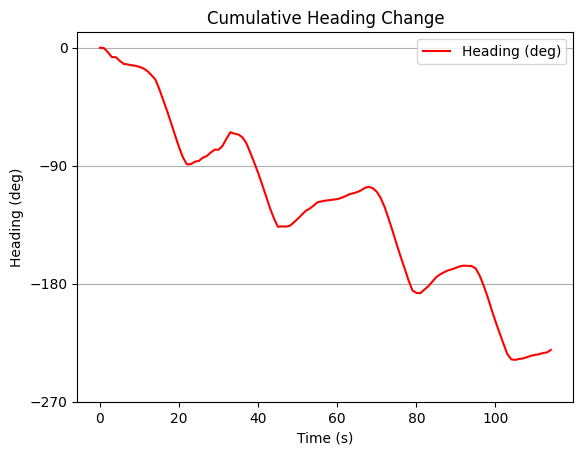

In [ ]:
import os
import numpy as np
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer
from src.trajectory_predictor import TrajectoryPredictor
import matplotlib.pyplot as plt
import joblib 
import random
import tensorflow as tf
from pathlib import Path

# 시드 값 고정
SEED = 1217  
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def main():
    BASE_DIR = os.getcwd()
    window_size = 200

    model_path = os.path.join(BASE_DIR, 'saved_models', 'model_20250824_163740.h5') #200, batch_size: 128
    

    trainer = ModelTrainer(window_size=window_size, num_features=8)
    trainer.load_model(model_path)
    
    predictor = TrajectoryPredictor(
        trainer.model,
        trainer.sensor_scalers,
        trainer.y_speed_scaler,
        trainer.y_hc_scaler,
        window_size=window_size
    )
    
    learn_data_paths = [
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_left01.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_left02.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_left03.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_left04.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_left05.csv'), 

    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_right01.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_right02.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_right03.csv'),

    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_lr01.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_lr02.csv'),
    

    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_left01.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_left02.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_left03.csv'),
    
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_right01.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_right02.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_right03.csv'),

    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_lr01.csv'),
    
    ]
    
    config = {
        'looking_left05.csv': {'skiprows': 500, 'flag': True,  'zone': 52},
        'looking_lr02.csv':   {'skiprows': 500, 'flag': True,  'zone': 52},
        'UTAH_looking_01.csv':{'skiprows': 1000,'flag': True,  'zone': 12},
        'UTAH_looking_02.csv':{'skiprows': 1000,'flag': True,  'zone': 12},
        'UTAH_looking_03.csv':{'skiprows': 1000,'flag': True,  'zone': 12},
        'UTAH_looking_04.csv':{'skiprows': 1000,'flag': True,  'zone': 12},
    }
    default_config = {'skiprows': 500, 'flag': False, 'zone': 52}
    
    X_list, Y_list = [], []
    df_list = []

    for path in learn_data_paths:
        if not os.path.exists(path):
            print(f"학습 파일을 찾을 수 없습니다: {path}")
            continue

        # 파일명으로 옵션 선택
        fname = Path(path).name
        opts = config.get(fname, default_config)

        # 언팩하여 함수 호출
        df_all, x, y = DataProcessor.load_and_preprocess_csv(path, **opts)

        df_list.append(df_all)
        X_list.append(x)
        Y_list.append(y)

    if not X_list:
        print("유효한 윈도우가 하나도 생성되지 않았습니다.")
        return
    
     # df_list와 Y_list를 zip으로 묶어서, 각각 GT(Y)와 함께 전달
    # for df_learn, Y_learn in zip(df_list, Y_list):
    #     predictor.compare_trajectories(df_learn)

    
   
    test_paths = [
        
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_l01.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_l02.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_l03.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_l04.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_l05.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_l06.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_l07.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_l08.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_l09.csv'),
        
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_r01.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_r02.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_r03.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_r04.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_r05.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_r06.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_r07.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_r08.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_r09.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_r10.csv'),
        
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_3loop_l01.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_3loop_r01.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_3loop_r02.csv'),
        
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_5loop_l01.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_5loop_l02.csv'),
        
        os.path.join(BASE_DIR, 'data', 'test_data', 'swing', 'test_swing_l01.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'swing', 'test_swing_l02.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'swing', 'test_swing_l03.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'swing', 'test_swing_l04.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'swing', 'test_swing_l05.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'swing', 'test_swing_l06.csv'),
        
        os.path.join(BASE_DIR, 'data', 'test_data', 'swing', 'test_swing_r01.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'swing', 'test_swing_r02.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'swing', 'test_swing_r03.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'swing', 'test_swing_r04.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'swing', 'test_swing_r05.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'swing', 'test_swing_r06.csv'),

        
    ]
    
    
    
    # 각 테스트 파일에 대해 예측 수행
    for test_path in test_paths:
        if os.path.exists(test_path):
            print(f"\n테스트 파일 처리 중: {os.path.basename(test_path)}")
            
            # 테스트 데이터 로드 및 전처리
            df_test = DataProcessor.load_and_preprocess_csv_test(test_path, skiprows=100)
            
            # 예측 경로 시각화
            predictor.predict_and_plot_trajectory(df_test, False)
            #predictor.predict_and_plot_trajectory(df_test, True)
            
        else:
            print(f"테스트 파일을 찾을 수 없습니다: {test_path}")

if __name__ == '__main__':
    main() 
    
